In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CatBoost

In [3]:
blocks = gpd.read_parquet('../data/traning_data/prepared_blocks.parquet')
blocks.head()

FileNotFoundError: [Errno 2] Failed to open local file '../data/traning_data/prepared_blocks.parquet'. Detail: [errno 2] No such file or directory

In [3]:
# cols_to_drop = [col for col in blocks.columns if col.startswith('capacity')]
# blocks = blocks.drop(columns=cols_to_drop)
# cols_to_drop = [col for col in blocks.columns if col.startswith('count')]
# blocks = blocks.drop(columns='cluster')
# blocks = blocks.drop(columns=cols_to_drop)

# blocks.columns

In [4]:
from urbanomy.methods.land_value_modeling.training_utils import TrainingConfig, run_training
import logging

# Флаг: учить с сервисами (count_*) или без
use_services = False   # False -> исключаем все count_* фичи

target_col = "log_total_price"
radius_list = [300, 500, 1000, 2000, 3000]

exclude_base = {
    "geometry",
    "log_price",
    "total_cost_value",
    "log_total_price",
    "price_per_sqm",
}

def is_service_col(col: str) -> bool:
    # сервисы у тебя обычно в формате count_...
    # если есть другие варианты (например Count_ / COUNT_), делаем lower()
    c = col.lower()
    return c.startswith("count_")

# формируем feature_cols с учетом флага
feature_cols = []
for c in blocks.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

cat_features = ["land_use", "morphotype"]

cfg = TrainingConfig(
    feature_cols=feature_cols,
    cat_features=cat_features,
    radius_list=radius_list,
    target_col=target_col,
    hpo_iter=24,
    n_clusters=10,
    inner_splits=5,
    outer_splits=5,
    iterations=1500,
    od_wait=300,
    seed=42,
)

model, metrics = run_training(
    blocks,
    cfg,
    log_path=f"catboost_info/training_{'with_services' if use_services else 'no_services'}.log",
    console_level=logging.WARNING,
)

print("use_services =", use_services)
print(metrics)


OuterCV:   0%|          | 0/5 [00:00<?, ?it/s]

Trials:   0%|          | 0/24 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

CatBoostError: Only one of parameters ['verbose', 'logging_level', 'verbose_eval', 'silent'] should be set

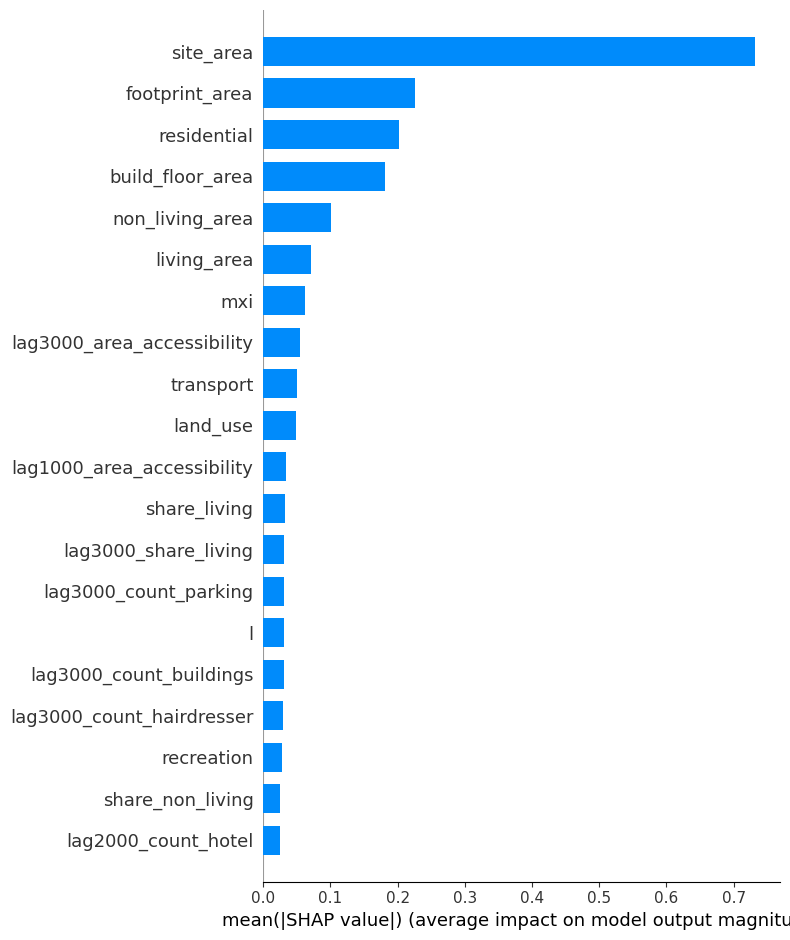

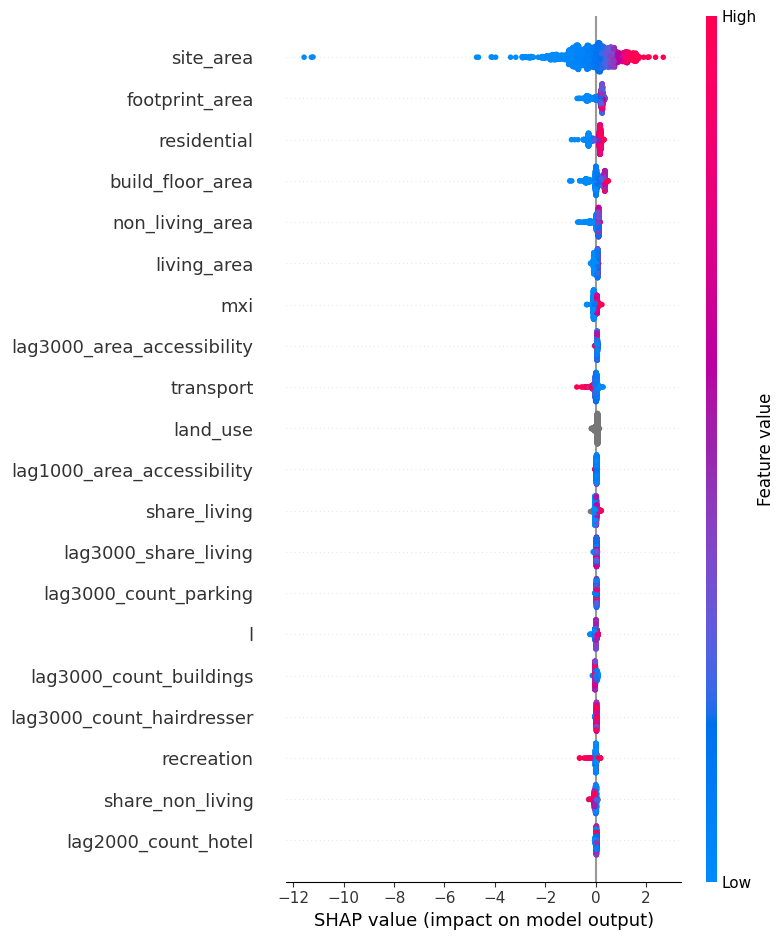

In [ ]:
from catboost import Pool
from urbanomy.methods.land_value_modeling.training_utils import spatial_groups, build_radii_weights, add_lags_full_df, feature_names
from sklearn.model_selection import GroupKFold
import shap

# 1) same outer split as in training (pick first fold)
groups = spatial_groups(blocks, cfg.n_clusters, random_state=cfg.seed)
_, test_idx = list(GroupKFold(n_splits=cfg.outer_splits).split(blocks, blocks[target_col], groups))[0]
df_test = blocks.iloc[test_idx].copy()

# 2) compute lags on FULL dataset once (so test "sees" neighbors from all blocks),
# then slice out test rows
cat_features = list(cfg.cat_features)
numeric_feats = [c for c in cfg.feature_cols if c not in cat_features and c != target_col]

blocks_all = blocks.copy()
for c in cat_features:
    blocks_all[c] = blocks_all[c].astype("string").fillna("missing")

weights = build_radii_weights(blocks_all, cfg.radius_list)
blocks_lag = add_lags_full_df(blocks_all, weights=weights, numeric_cols=numeric_feats)

# 3) final feature list = base feature_cols + computed lag / n_neighbors cols
base_cols_for_model = list(dict.fromkeys(list(cfg.feature_cols) + cat_features))
feats = feature_names(blocks_lag, base_cols_for_model, target_col)

df_test_lag = blocks_lag.loc[df_test.index]

# 4) sample for SHAP
sample_df = df_test_lag[feats].sample(n=min(1500, len(df_test_lag)), random_state=42)
sample_pool = Pool(sample_df, cat_features=cat_features, feature_names=feats)

# 5) SHAP
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(sample_pool, check_additivity=False)

shap.summary_plot(shap_vals, sample_df, plot_type="bar")
shap.summary_plot(shap_vals, sample_df)


In [ ]:
import json

artifacts = {
    "feature_cols": list(cfg.feature_cols),
    "cat_features": list(cfg.cat_features),
    "radius_list": list(cfg.radius_list),
    "target_col": cfg.target_col,
    "n_clusters": cfg.n_clusters,
    "seed": cfg.seed,
}

with open("artifacts.json", "w") as f:
    json.dump(artifacts, f, indent=2)

In [ ]:
with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

In [ ]:


model_path = "land_value_catboost_22_12.cbm"
model.save_model(model_path)

print(f"Model saved to {model_path}")

Model saved to land_value_catboost_22_12.cbm
